# 05b · Accessibility features for every listing 

**What this notebook does, in plain language**

1. Builds one listings table from every snapshot we have (today: Domain, Sept 2025; later: rent.com.au, Sept 2026).
2. Puts every listing inside its ABS **SA2 district** and attaches that district's population, population growth,
   population projection and income.
3. Measures how close every listing is to **train stations, schools, parks, shopping centres and entertainment**
   (restaurants, cafes, pubs, bars, cinemas, theatres).
4. Measures **driving distance by road** from each suburb to the **Melbourne CBD** and to its **nearest train station**.
5. Saves `data/curated/listings_features.parquet` (one row per listing) and `suburb_features.parquet` (one row per suburb and snapshot).

When the 2026 data is added, re-running this notebook adds it automatically. Car routes already calculated are
saved in `route_cache.parquet`, so only new suburbs are sent to the routing service.

Data sources: ABS ASGS 2021 SA2 boundaries; ABS Regional Population 2001–25; ABS Personal Income in Australia
2018-19 to 2022-23 (Table 1.4); PTV GTFS timetable (train stations); Victorian Department of Education school
locations 2025; OpenStreetMap via the Overpass API; car routes from the OSRM routing service (OpenStreetMap roads).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "scripts"))   # shared project code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config, style
import listings as L
style.apply()
import geo

## 1. All listings, all snapshots

In [2]:
df = L.build_listings()   # stacks every snapshot whose file exists, same columns for all
df.groupby(["snapshot", "source"]).agg(listings=("listing_id", "size"), usable_for_analysis=("usable", "sum"))

,,listings,usable_for_analysis
snapshot,source,,
2025-09,domain,12717,12291


`usable` rows are residential listings with a plausible rent ($100–$10,000 a week), valid coordinates and
sensible room counts. Nothing is deleted; the other rows are only flagged.

## 2. SA2 district, population and income

In [3]:
sa2 = geo.load_sa2_vic()
sa2_feat = geo.sa2_features()
df = geo.attach_sa2(df, sa2).merge(sa2_feat, on="SA2_CODE21", how="left")
print(f"Listings placed in an SA2: {df['SA2_CODE21'].notna().mean():.1%}")
print(f"SA2 districts with at least one listing: {df['SA2_CODE21'].nunique()} of {len(sa2)}")
print("Population projection source:", sa2_feat["POP_PROJ_SOURCE"].iloc[0])
sa2_feat.drop(columns="POP_PROJ_SOURCE").describe().T[["count", "mean", "50%"]].round(3)

Listings placed in an SA2: 100.0%
SA2 districts with at least one listing: 480 of 522
Population projection source: ABS ERP 2020-25 trend (VIF2023 file not found)


,count,mean,50%
POP_2025,522.0,13551.454,13390.500
POP_GROWTH_2020_2025,519.0,0.010,0.004
POP_PROJ_2031,519.0,15417.018,13857.612
POP_PROJ_GROWTH_2026_2031,519.0,0.010,0.004
EARNERS_2022_23,520.0,8498.444,8015.000
MEDIAN_INCOME_2018_19,521.0,48306.305,48614.000
MEDIAN_INCOME_2022_23,520.0,57775.175,57558.500
MEAN_INCOME_2022_23,520.0,72484.165,68133.000
INCOME_GROWTH_2019_2023,520.0,0.046,0.044


*Population projection:* the official Victoria in Future 2023 file could not be downloaded automatically
(the website blocks scripts). Until it is placed at `data/raw/external/VIF2023_SA2_Pop_Hhold_Dwelling_Projections_to_2036_Release_2.xlsx`,
each SA2's 2020–25 growth rate is continued forward. Once the file is there, `geo.sa2_features()` switches to it with no other change.

## 3. Nearby amenities (straight-line distance)

In [4]:
pois = {
    "train": geo.train_stations(),
    "school": geo.schools(),
    "park": geo.osm_pois("parks"),
    "shop": geo.osm_pois("shopping"),
    "entertainment": geo.osm_pois("entertainment"),
}
fun = ["restaurant", "cafe", "pub", "bar", "cinema", "theatre", "nightclub", "arts_centre"]
pois["entertainment"] = pois["entertainment"][pois["entertainment"]["kind"].isin(fun)]
pd.Series({k: len(v) for k, v in pois.items()}, name="locations in Victoria").to_frame()

,locations in Victoria
train,320
school,2301
park,18661
shop,2091
entertainment,11537


In [5]:
has_xy = df["lat"].notna() & df["lon"].notna() & ~df["flag_bad_coordinates"]
xy = df.loc[has_xy]
cbd = pd.DataFrame({"name": ["Melbourne CBD"], "lat": [config.MELBOURNE_CBD[0]], "lon": [config.MELBOURNE_CBD[1]]})
feats = pd.concat([
    geo.nearest(xy, pois["train"], "train"),
    geo.nearest(xy, pois["school"], "school"),
    geo.nearest(xy, pois["park"], "park"),
    geo.nearest(xy, pois["shop"], "shop"),
    geo.nearest(xy, cbd, "cbd")[["cbd_km"]],
    geo.count_within(xy, pois["school"], 2, "schools_within_2km"),
    geo.count_within(xy, pois["park"], 1, "parks_within_1km"),
    geo.count_within(xy, pois["shop"], 2, "shops_within_2km"),
    geo.count_within(xy, pois["entertainment"], 1, "entertainment_within_1km"),
], axis=1)
df = df.join(feats)
feats.select_dtypes("number").describe().T[["mean", "25%", "50%", "75%", "max"]].round(2)

,mean,25%,50%,75%,max
train_km,3.85,0.66,1.29,2.63,189.94
school_km,0.71,0.35,0.54,0.78,28.46
park_km,0.27,0.14,0.22,0.32,11.00
shop_km,0.95,0.33,0.63,1.07,55.92
cbd_km,36.72,7.46,19.17,36.56,482.30
schools_within_2km,8.04,4.00,8.00,11.00,23.00
parks_within_1km,15.56,8.00,14.00,20.00,81.00
shops_within_2km,14.44,4.00,9.00,17.00,86.00
entertainment_within_1km,61.88,1.00,7.00,41.00,1181.00


## 4. Driving distance by road (Sprint 3 minimum)

Routes are calculated from each **suburb's centre** (the median location of its listings) rather than for every
listing, to keep the number of requests small (the same plan as `05_geospatial_routing`). For the station, the three
closest stations in a straight line are all routed and the shortest drive is kept, because the closest station
"as the crow flies" is not always the closest by road. The per-listing straight-line distances above keep the
variation inside each suburb.

In [6]:
centres = df[has_xy].groupby("suburb_key")[["lat", "lon"]].median()
routes = geo.route_features(centres, pois["train"])
centres = centres.join(routes[["cbd_route_km", "train_route_km", "train_route_station"]])
print(f"Suburb centres with a CBD route: {centres['cbd_route_km'].notna().sum()} of {len(centres)}")
print(f"Suburb centres with a station route: {centres['train_route_km'].notna().sum()} of {len(centres)}")
df = df.merge(centres[["cbd_route_km", "train_route_km", "train_route_station"]],
              left_on="suburb_key", right_index=True, how="left")

straight = df.groupby("suburb_key")["cbd_km"].median()
ratio = (centres["cbd_route_km"] / straight).median()
print(f"Driving distance is typically {ratio:.2f}x the straight-line distance to the CBD")
centres[["cbd_route_km", "train_route_km"]].describe().T.round(1)

Suburb centres with a CBD route: 653 of 653
Suburb centres with a station route: 653 of 653
Driving distance is typically 1.20x the straight-line distance to the CBD


,count,unique,top,freq
cbd_route_km,653.0,653.0,3.9,1.0
train_route_km,653.0,652.0,2.2,2.0


## 5. Save listing-level and suburb-level tables

In [7]:
df.to_parquet(config.LISTINGS_FEATURES, index=False)

use = df[df["usable"]]
dist_cols = ["train_km", "school_km", "park_km", "shop_km", "cbd_km", "schools_within_2km",
             "parks_within_1km", "shops_within_2km", "entertainment_within_1km", "cbd_route_km", "train_route_km"]
most_common = lambda s: s.mode().iat[0] if s.notna().any() else None
suburbs = (use.groupby(["snapshot", "suburb_key"])
              .agg(suburb=("suburb", "first"), postcode=("postcode", "first"),
                   listings=("listing_id", "size"), median_rent=("weekly_rent", "median"),
                   median_days_listed=("days_listed", "median"),
                   share_house=("property_group", lambda s: (s == "House").mean()),
                   median_bedrooms=("bedrooms", "median"),
                   lat=("lat", "median"), lon=("lon", "median"), SA2_CODE21=("SA2_CODE21", most_common),
                   **{c: (c, "median") for c in dist_cols})
              .reset_index()
              .merge(sa2_feat, on="SA2_CODE21", how="left"))
suburbs.to_parquet(config.SUBURB_FEATURES, index=False)
print(f"Saved {len(df):,} listings and {len(suburbs):,} suburb rows")

Saved 12,717 listings and 644 suburb rows


## 6. Maps

The first map is the property-location map (Sprint 1/2), drawn once per snapshot, so a 2026 map appears
automatically once that data is loaded.

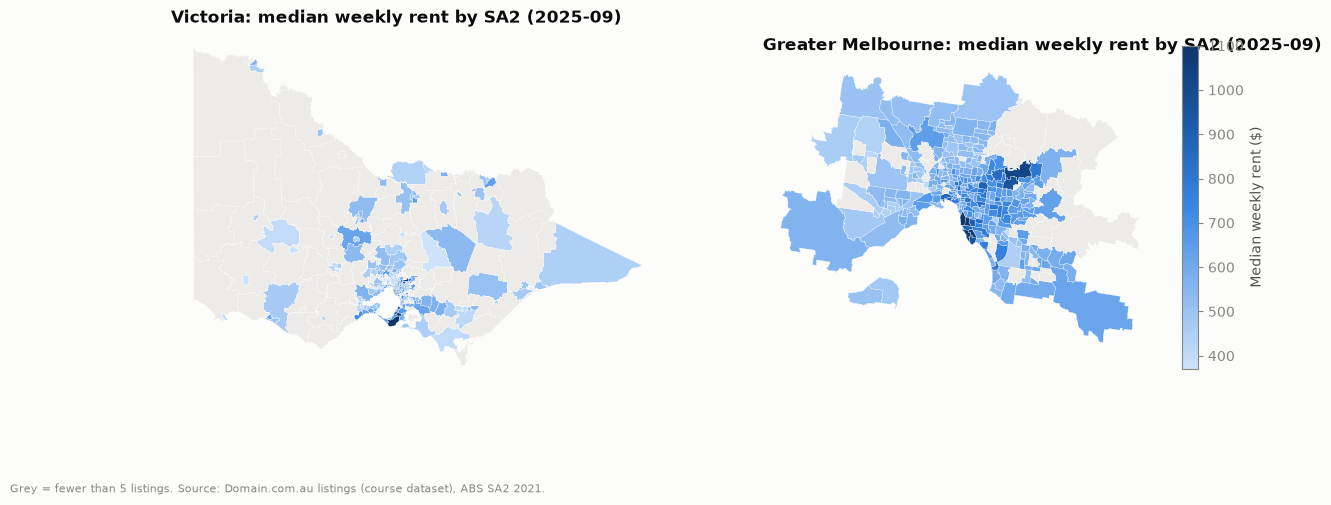

In [8]:
vmin, vmax = use["weekly_rent"].quantile([0.05, 0.95])
for snap, g in use.groupby("snapshot"):
    rent = g.groupby("SA2_CODE21")["weekly_rent"].agg(["median", "size"])
    m = sa2.merge(rent[rent["size"] >= 5], left_on="SA2_CODE21", right_index=True, how="left")
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    views = [(axes[0], None, "Victoria"), (axes[1], (144.55, 145.45, -38.15, -37.55), "Greater Melbourne")]
    for ax, box, title in views:
        part = m if box is None else m.cx[box[0]:box[1], box[2]:box[3]]
        part.plot(column="median", cmap=style.SEQ, vmin=vmin, vmax=vmax, ax=ax, edgecolor="white",
                  linewidth=0.2, missing_kwds={"color": "#ecebe7"}, legend=ax is axes[1],
                  legend_kwds={"label": "Median weekly rent ($)", "shrink": 0.7})
        ax.set_title(f"{title}: median weekly rent by SA2 ({snap})")
        ax.set_axis_off()
    fig.text(0.01, 0.02, "Grey = fewer than 5 listings. Source: Domain.com.au listings (course dataset), ABS SA2 2021.",
             color=style.MUTED, fontsize=8)
    fig.savefig(config.PLOTS / f"map_sa2_median_rent_{snap}.png", dpi=150, bbox_inches="tight")
    plt.show()

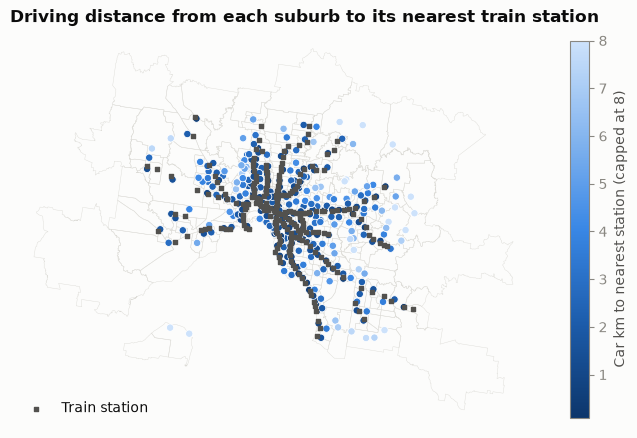

In [9]:
box = centres[centres["lon"].between(144.55, 145.45) & centres["lat"].between(-38.15, -37.55)]
fig, ax = plt.subplots(figsize=(8.5, 7))
sa2.cx[144.55:145.45, -38.15:-37.55].boundary.plot(ax=ax, color="#dcdbd6", linewidth=0.3)
pts = ax.scatter(box["lon"], box["lat"], c=box["train_route_km"].clip(upper=8), cmap=style.SEQ.reversed(),
                 s=28, edgecolor="white", linewidth=0.6, zorder=3)
st = pois["train"]
st = st[st["lon"].between(144.55, 145.45) & st["lat"].between(-38.15, -37.55)]
ax.scatter(st["lon"], st["lat"], marker="s", s=8, color=style.INK_2, zorder=4, label="Train station")
fig.colorbar(pts, ax=ax, shrink=0.7, label="Car km to nearest station (capped at 8)")
ax.set_title("Driving distance from each suburb to its nearest train station")
ax.legend(loc="lower left")
ax.set_axis_off()
fig.savefig(config.PLOTS / "map_train_route_km.png", dpi=150, bbox_inches="tight")
plt.show()